# 使用 Open-RAG-Eval 评测 RAG

你会学到：

- 用 Open-RAG-Eval 读取一份“RAG 输出 CSV”（query / retrieved passages / generated answer）
- 跑一轮批量评测（retrieval + generation）
- 解读几类常见指标输出，并把结果汇总成可视化图表


## RAG Evaluation outputs

Open-RAG-Eval 期望你的 RAG 结果以一种“可评测”的结构提供。

在这个示例里，我们直接使用一个已经整理好的 CSV（`fiqa_output.csv`）：

- 每一行是一条 query
- 包含检索到的 passages
- 包含模型生成的答案（以及可选的 citation 信息）

后面我们会用 `RAGResultsLoader` 把 CSV 解析成 Open-RAG-Eval 的结果对象，再交给 evaluator 批量评测。

In [1]:
import os
from pathlib import Path

import matplotlib.image as mpimg
import matplotlib.pyplot as plt
import pandas as pd
import requests
from dotenv import load_dotenv

from open_rag_eval.evaluators import TRECEvaluator
from open_rag_eval.models.llm_judges import OpenAIModel
from open_rag_eval.rag_results_loader import RAGResultsLoader

DATA_DIR = Path("./data")
DATA_DIR.mkdir(parents=True, exist_ok=True)

╭───────────────────────────────────────────── 🚀 New SDK Available ──────────────────────────────────────────────╮
│ Together Python SDK 2.0 is now available!                                                                       │
│                                                                                                                 │
│ Install the beta:                                                                                               │
│ pip install --pre together  or  uv add together --prerelease allow                                              │
│                                                                                                                 │
│ New SDK: ]8;id=11893257;https://github.com/togethercomputer/together-py\https://github.com/togethercomputer/together-py]8;;\                                                        │
│ Migration guide: ]8;id=11893258;https://docs.together.ai/docs/pythonv2-migration-guide\https://docs.together.ai/docs/pythonv2-migration-guide]8;;\                                         │
│                                                                                                                 │
│ This package will be maintained until January 2026.                                                             │
│ Set TOGETHER_NO_BANNER=1 to hide this message.                                                                  │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

In [2]:
import os
os.environ["HTTP_PROXY"] = "http://127.0.0.1:7890"
os.environ["HTTPS_PROXY"] = "http://127.0.0.1:7890"
os.environ["ALL_PROXY"] = "http://127.0.0.1:7890"

`fiqa_output.csv` 采用的是 Open-RAG-Eval 期望的 CSV 格式。

你可以先把它当作“RAG 系统的离线输出文件”：

- 你可以用自己的 RAG 跑一遍，把结果也整理成同样结构的 CSV
- 然后复用下面的评测流程，对不同系统/不同配置做对比


In [3]:
DATASET_URL = "https://raw.githubusercontent.com/vectara/example-notebooks/main/data/fiqa_output.csv"
DATASET_PATH = DATA_DIR / "fiqa_output.csv"
MAX_ROWS = 50  # 为了演示速度，先只跑前 50 行

def download_file(url: str, dst: Path, *, timeout_s: float = 60.0) -> Path:
    dst.parent.mkdir(parents=True, exist_ok=True)
    if dst.exists() and dst.stat().st_size > 0:
        return dst

    r = requests.get(url, timeout=timeout_s)
    r.raise_for_status()
    dst.write_bytes(r.content)
    return dst


csv_path = download_file(DATASET_URL, DATASET_PATH)

df = pd.read_csv(csv_path).fillna("")
df = df.head(MAX_ROWS)
df.head(10)

,query_id,query,passage_id,passage,generated_answer
0,8311fbce-c34a-43da-9bfe-24b72c2d3a0c,accredited investor definition,[1],Here are the SEC requirements: The federal se...,"Based on the provided sources, an accredited i..."
1,8311fbce-c34a-43da-9bfe-24b72c2d3a0c,accredited investor definition,[2],"""The (U.S) """"accredited investor"""" laws apply...",
2,8311fbce-c34a-43da-9bfe-24b72c2d3a0c,accredited investor definition,[3],Accredited investors are required to have 1 m...,
3,8311fbce-c34a-43da-9bfe-24b72c2d3a0c,accredited investor definition,[4],Does me holding stock in the company make me ...,
4,8311fbce-c34a-43da-9bfe-24b72c2d3a0c,accredited investor definition,[5],SecondMarket attempts to add liquidity to pri...,
5,45332c9d-14de-4107-b136-b71f6673b8e2,what is the purpose of a job training,[1],I'm not saying I don't like the idea of on-th...,"Based on the provided sources, the purpose of ..."
6,45332c9d-14de-4107-b136-b71f6673b8e2,what is the purpose of a job training,[2],"A lot of jobs, if not most, just don't requir...",
7,45332c9d-14de-4107-b136-b71f6673b8e2,what is the purpose of a job training,[3],&gt; but we as a society do not even offer en...,
8,45332c9d-14de-4107-b136-b71f6673b8e2,what is the purpose of a job training,[4],"We also have for-profit, career-oriented scho...",
9,45332c9d-14de-4107-b136-b71f6673b8e2,what is the purpose of a job training,[5],"What about electrician, plumber, welder, cons...",


## 运行一轮 Open-RAG-Eval 评测

这里我们做三件事：

- 从 `.env` 读取 `OPENAI_API_KEY`
- 构造一个 judge LLM（OpenAI）
- 读取 CSV 的 RAG 结果并批量评测


In [4]:
load_dotenv()

judge_model = OpenAIModel(
    {
        "name": "gpt-4o-mini",
        "api_key": os.getenv("OPENAI_API_KEY"),
    }
)

evaluator = TRECEvaluator(model=judge_model)

multi_rag_results = RAGResultsLoader(str(DATASET_PATH)).load()
multi_rag_results = multi_rag_results[:MAX_ROWS]

scored_results = evaluator.evaluate_batch(multi_rag_results)
len(scored_results)

You are using a model of type HHEMv2Config to instantiate a model of type HHEMv2. This is not supported for all configurations of models and can yield errors.
Evaluating using TRECEvaluator evaluator.: 100%|██████████| 10/10 [01:12<00:00,  7.25s/it]


10

Note：你可能会看到类似“Token indices sequence length is longer than ...”的警告。

这个示例里我们主要关注评测结果本身；如果你要在真实场景中评测更长的 context/更长的答案，再结合模型上下文长度与截断策略去处理。

## 查看评测结果

`scored_results` 里每一项都包含：

- 原始的 RAG 输出（query、检索结果、生成答案等）
- 评测得到的各类分数（retrieval 侧 + generation 侧）

下面我们挑一条样本，把关键的结构和分数打印出来。

In [5]:
import pprint

pp = pprint.PrettyPrinter(indent=4, width=80)

multi_scored = scored_results[0]
scored_result = multi_scored.scored_rag_results[0]
scores = scored_result.scores

pp.pprint(f"Query: {scored_result.rag_result.retrieval_result.query}")
pp.pprint("------")

num_results_to_show = 5
for key, passage in scored_result.rag_result.retrieval_result.retrieved_passages.items():
    pp.pprint(f"Passage: {passage}")
    pp.pprint(f"Score: {scores.retrieval_score.scores['umbrela_scores'][key]}")
    pp.pprint("------")

    num_results_to_show -= 1
    if num_results_to_show == 0:
        break

'Query: canadian importers trade in cny'
'------'
('Passage:  Chinese suppliers can quote their price in CNY rather than USD (as '
 'has been typical), and thus avoid the exchange risk from US dollar '
 'volatility- the CNY has been generally appreciating so committing to receive '
 'payments in US dollars when their costs are in CNY means they are typically '
 'on the losing end of the equation and they have to pad their prices a bit.  '
 'Canadian importers will have to buy RMB (typically with CAD) to pay for '
 'their orders and Canadian exporters can take payment in RMB if they wish, or '
 'set prices in CAD. By avoiding the US dollar middleman the transactions are '
 'made less risky and incur less costs. Japan did this many decades ago (they, '
 'too, used to price their products in USD).  This is important in '
 'transactions of large amounts, not so much for the tiny amounts associated '
 'with tourism. Two-way annual trade between China and Canada is in excess of '
 '$70bn.  O

### AutoNuggetizer Metric

Open-RAG-Eval 会把生成答案拆解成更细的“信息单元（nuggets）”，并评估：

- 每个 nugget 的重要性（importance）
- 这个 nugget 是否被答案支持/覆盖（support）

先把答案（含 citations）重建出来，再逐条看 nugget。

In [6]:
autonuggetizer_scores = scores.generation_score.scores["autonugget_scores"]

# 生成答案在数据结构里被拆成：text + citations（为了展示，这里重建成一条字符串）
recreated_answer: list[str] = []
for part in scored_result.rag_result.generation_result.generated_answer:
    recreated_answer.append(part.text)
    for citation in part.citations:
        recreated_answer.append(citation)

generated_answer = " ".join(recreated_answer)
pp.pprint(f"Generated Answer: {generated_answer}")

for nugget, importance, support in zip(
    autonuggetizer_scores["nuggets"],
    autonuggetizer_scores["labels"],
    autonuggetizer_scores["assignments"],
):
    pp.pprint(f"Nugget: {nugget}, Importance: {importance}, Support: {support}")

('Generated Answer: Canadian importers can trade in CNY (Chinese Yuan) by '
 'buying RMB (Renminbi) with CAD (Canadian Dollar) to pay for their orders [1] '
 '. This allows them to avoid the exchange risk from US dollar volatility and '
 'incur less costs [1] . In fact, two-way annual trade between China and '
 'Canada is in excess of $70bn, making it an important part of the Canadian '
 'economy [1] . By trading in CNY, Canadian importers can benefit from the '
 'appreciation of the CNY, which can make goods from other countries more '
 'competitive and imports from China more expensive [3] . This can lead to a '
 'shift in trade patterns, with Canadian importers potentially sourcing more '
 'from countries that use the CNY as their currency [3]')
('Nugget: Canadian importers can pay in CNY instead of USD, Importance: '
 'NuggetImportanceValues.VITAL, Support: NuggetAssignmentValues.SUPPORT')
('Nugget: CNY avoids US dollar exchange risk, Importance: '
 'NuggetImportanceValues.VITAL, S

### Hallucination Metric

这一项关注“生成答案里是否出现了不被检索证据支持的内容”。

我们先直接把它的分数结构打印出来。

In [7]:
print("Hallucination Score:", scores.generation_score.scores["hallucination_score"])

Hallucination Score: 0.8428818583488464


### Citation Metric

这一项关注“答案中的引用（citation）是否合理”。

同样先直接输出它的分数结构。

In [8]:
print("Citation Scores:")
scores.generation_score.scores["citation_scores"]

Citation Scores:


{'citation_score_[1]': 1.0,
 'citation_score_[3]': 0.5,
 'part_score_1': 1.0,
 'part_score_2': 1.0,
 'part_score_3': 1.0,
 'part_score_4': 0.5,
 'part_score_5': 0.5,
 'weighted_precision': 0.75,
 'weighted_recall': 0.8,
 'f1': 0.7741935483870969}

## 绘图汇总

最后把本次评测的结果保存成 CSV，并用 Open-RAG-Eval 的工具函数把指标画成一张汇总图。

In [9]:
# 保存评测结果到 CSV

evaluator.to_csv(scored_results, output_file="evaluation_results.csv")

# 绘制指标汇总图
TRECEvaluator.plot_metrics(
    csv_files=["evaluation_results.csv"],
    output_file="metrics_summary.png",
)

TREC scores saved to evaluation_results.csv
TREC metrics plot saved to metrics_summary.png


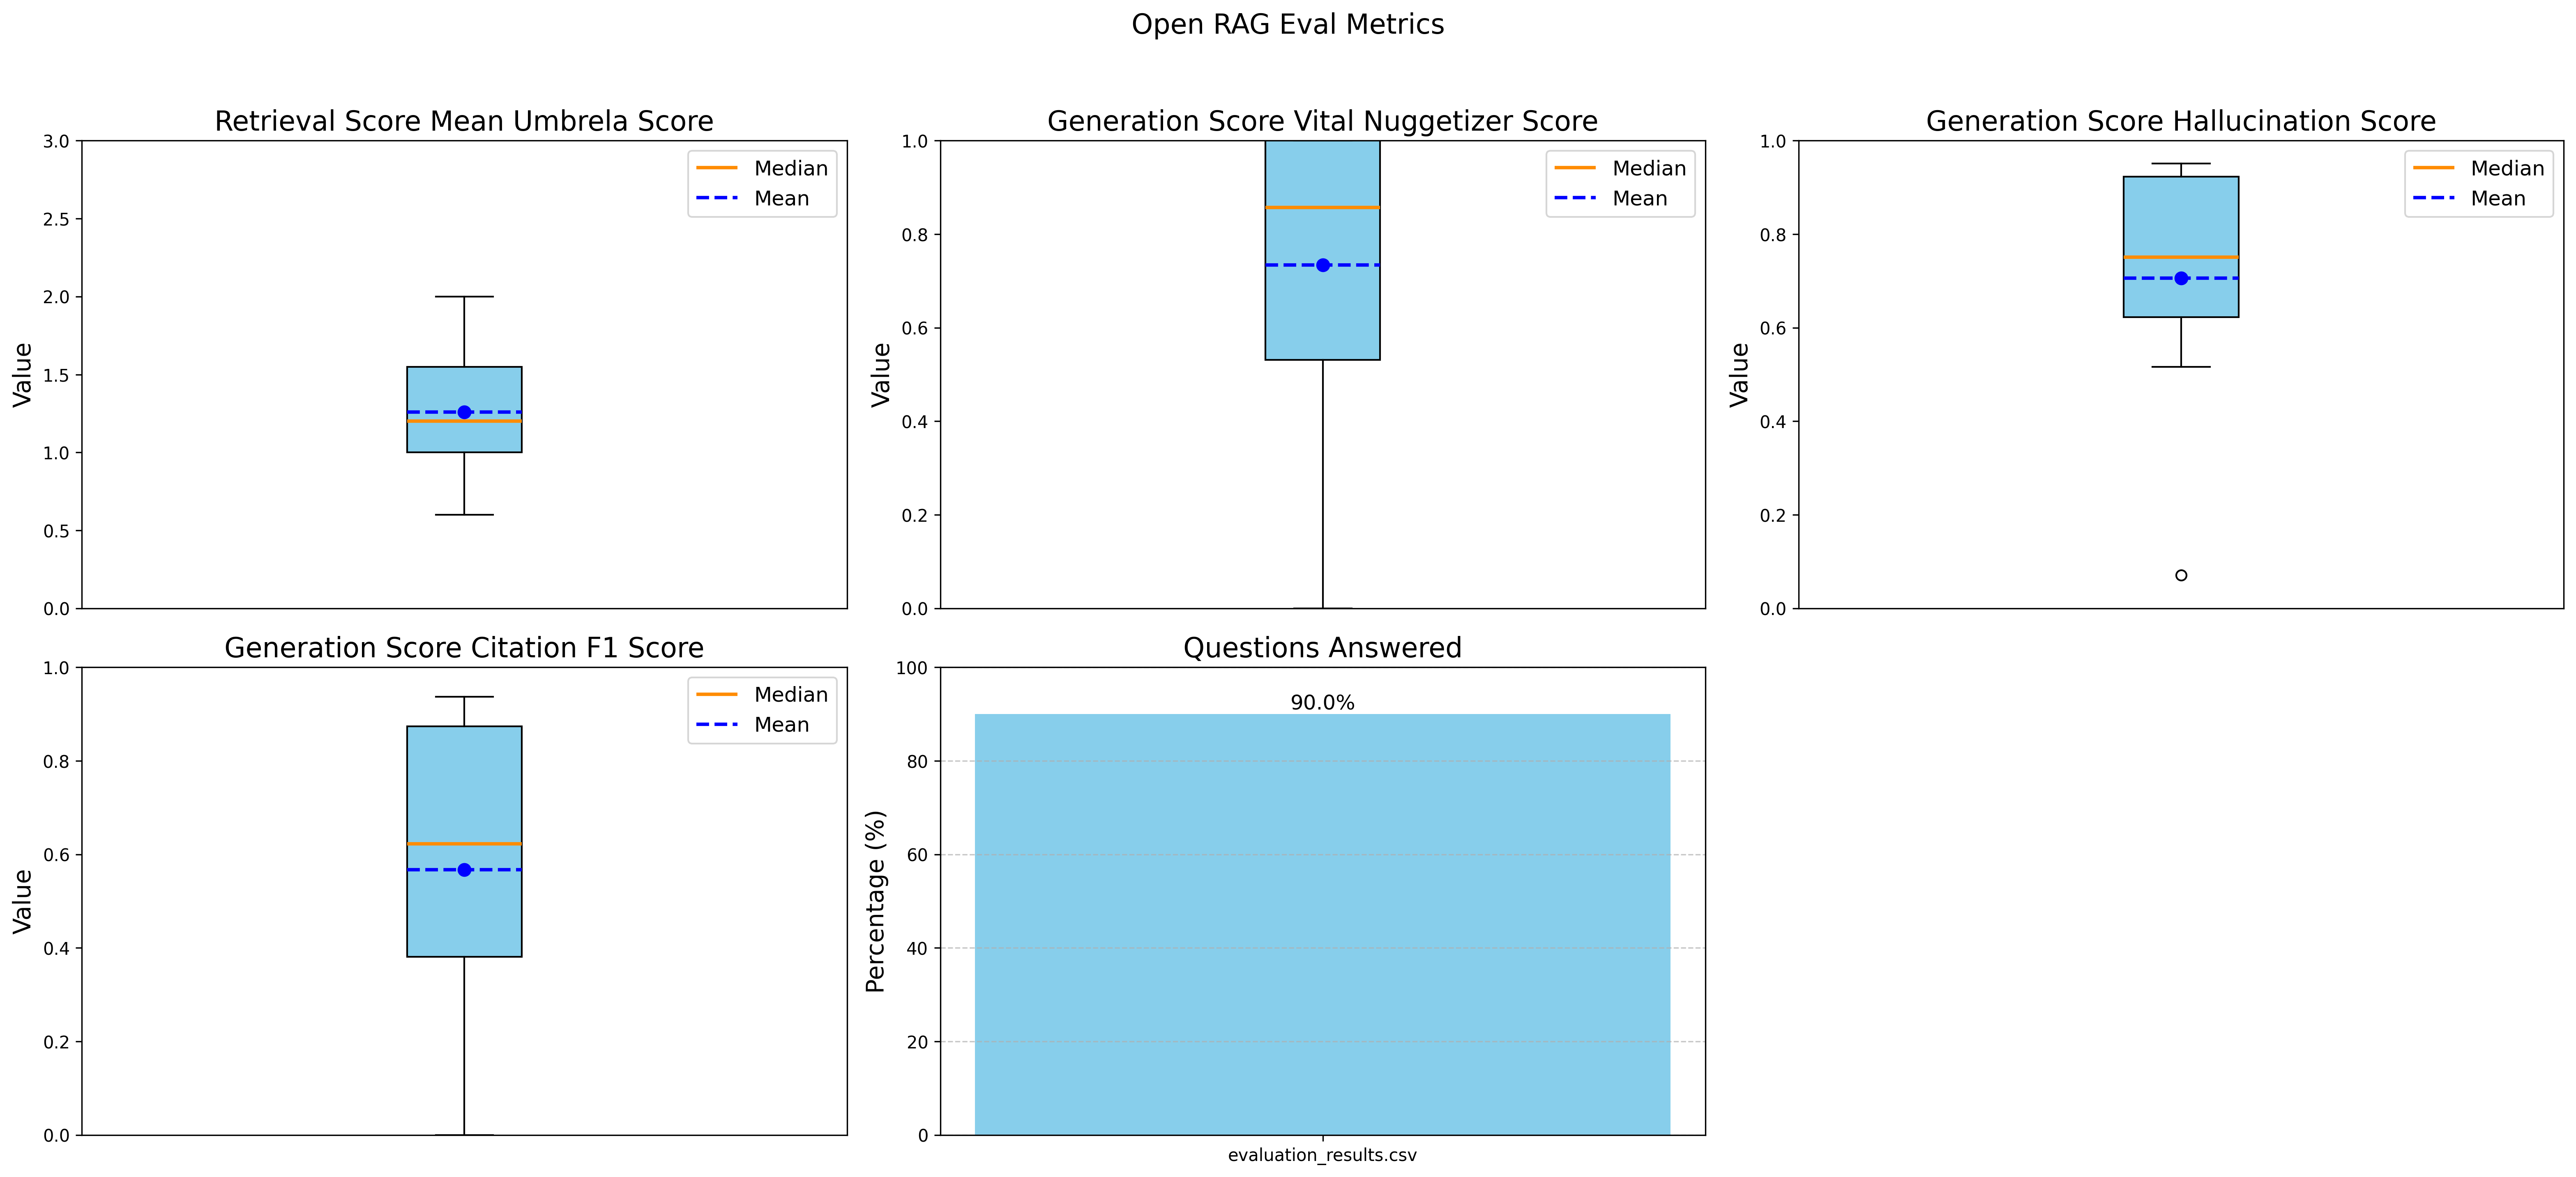

In [ ]:
from pathlib import Path
from IPython.display import Image, display

png_path = Path("metrics_summary.png").resolve()
display(Image(filename=str(png_path)))

## Summary

- 用 `RAGResultsLoader` 读取 RAG 输出数据（这里用 FIQA 的示例 CSV）
- 用 `TRECEvaluator` + `OpenAIModel` 跑批量评测，得到 retrieval / generation 两侧的评分
- 选取单条样本解读 UMBRELA / AutoNuggetizer / Hallucination / Citation 等指标结构
- 保存结果并画出汇总图，便于整体对比与回归
